In [52]:
import numpy as np
from numpy.linalg import pinv as inv
import pandas as pd
import glob
import os
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

from sklearn.datasets import make_spd_matrix
from sklearn.covariance import graphical_lasso, GraphicalLasso, GraphicalLassoCV
from tqdm.notebook import tqdm

from scipy.cluster import hierarchy
from scipy.spatial.distance import squareform
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
import scipy.cluster.hierarchy as sch
from scipy.stats import chi2

from numpy.lib.stride_tricks import sliding_window_view

from statsmodels.stats.multitest import fdrcorrection
from statsmodels.tsa.seasonal import STL

%matplotlib inline

# fix random seed
np.random.seed(39)

import warnings
warnings.filterwarnings('ignore')  # <- remember to comment this if something breaks and you get confused

In [53]:
def is_pos_def(A):
    if is_symmetric(A):
        try:
            np.linalg.cholesky(A)
            return True
        except np.linalg.LinAlgError:
            return False
    else:
        return False

def is_symmetric(a, tol=1e-8):
    return np.all(np.abs(a-a.T) < tol)

In [54]:
stock_files = os.path.join("/home/dink/Documents/Research/data/stocks", "*.csv")
stock_list = glob.glob(stock_files)

In [55]:
dfs = []
for filename in stock_list:
    sample_df = pd.read_csv(filename)
    head_tail = os.path.split(filename)
    stock_name = head_tail[1].split('.')[0]
    sample_df['Stock'] = ''.join(stock_name)
    dfs.append(sample_df)


df = pd.concat(dfs, axis=0, ignore_index=True)
df = df.loc[:, ["Date", "Close", "Stock"]]
df = df.pivot(index="Date", columns="Stock", values="Close")

In [56]:
df.head()

Stock,AMC,CLX,ETSY,FB,GME,NFLX,NVDA,PFE,PYPL,SPY,TSLA,TSM
Date,,,,,,,,,,,,
2017-02-22,31.350000,135.919998,12.90,136.119995,26.260000,143.860001,27.690001,31.869070,42.419998,236.279999,54.702000,32.070000
2017-02-23,31.350000,135.830002,12.51,135.360001,25.559999,142.779999,25.122499,32.314991,42.529999,236.440002,51.198002,31.750000
2017-02-24,31.400000,136.369995,12.72,135.440002,26.280001,143.250000,25.365000,32.504745,43.070000,236.740005,51.400002,31.920000
2017-02-27,31.450001,136.440002,12.79,136.410004,26.520000,143.410004,26.102501,32.523720,42.639999,237.110001,49.245998,31.530001
2017-02-28,31.350000,136.809998,12.12,135.539993,24.440001,142.130005,25.370001,32.371918,42.000000,236.470001,49.998001,31.469999


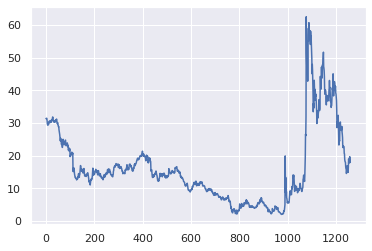

In [57]:
plt.plot(df.loc[:, 'AMC'].values)

In [58]:
seasonal_df = pd.DataFrame()
trend_df = pd.DataFrame()
resid_df = pd.DataFrame()
for i in tqdm(range(df.shape[1])):
    model = STL(df.values[:, i], period=252) # very approximate seasonality here, holidays+weekends etc
    result = model.fit()
    seasonal_df[df.columns[i]] = result.seasonal
    trend_df[df.columns[i]] = result.trend
    resid_df[df.columns[i]] = result.resid
seasonal_df.index = df.index
trend_df.index = df.index
resid_df.index = df.index

  0%|          | 0/12 [00:00<?, ?it/s]

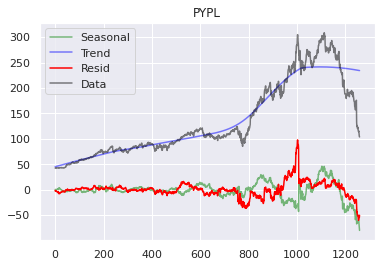

In [59]:
plot_idx = 8
plt.plot(seasonal_df.values[:, plot_idx], color='green', label='Seasonal', alpha=0.5)
plt.plot(trend_df.values[:, plot_idx], color='blue', label='Trend', alpha=0.5)
plt.plot(resid_df.values[:, plot_idx], color='red', label='Resid')
plt.plot(df.values[:, plot_idx], color='black', label='Data', alpha=0.5)
plt.title(seasonal_df.columns[plot_idx]);
plt.legend(loc='best');

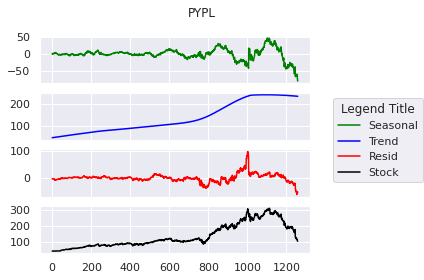

In [60]:
fig, (ax1, ax2, ax3, ax4) = plt.subplots(4)

line_labels = ['Seasonal', 'Trend', 'Resid', 'Stock']
l1 = ax1.plot(seasonal_df.values[:, plot_idx], color='green')
l2 = ax2.plot(trend_df.values[:, plot_idx], color='blue')
l3 = ax3.plot(resid_df.values[:, plot_idx], color='red')
l4 = ax4.plot(df.values[:, plot_idx], color='black')
fig.legend([l1, l2, l3, l4],     # The line objects
           labels=line_labels,   # The labels for each line
           loc="center right",   # Position of legend
           borderaxespad=0.1,    # Small spacing around legend box
           title="Legend Title"  # Title for the legend
           )
plt.subplots_adjust(right=0.75)
plt.suptitle(seasonal_df.columns[plot_idx]);

In [61]:
from sklearn import covariance, preprocessing

scaler = preprocessing.StandardScaler()
resid_scaled = scaler.fit_transform(resid_df.values)
resid_scaled

array([[ 0.85993209, -0.37871229,  0.35322936, ...,  0.34652282,
         0.28819412,  0.16827596],
       [ 0.77310692, -0.48900819,  0.25675531, ...,  0.14818307,
         0.16319952, -0.0147026 ],
       [ 0.70714191, -0.5432549 ,  0.37580764, ..., -0.08262176,
         0.09169055, -0.07948732],
       ...,
       [-1.19769812,  0.09944201, -2.54901867, ..., -1.23978161,
        -1.52467664, -2.01055348],
       [-1.27634945,  0.3779115 , -2.87072812, ..., -1.44433738,
        -1.76973203, -2.34062276],
       [-1.4421088 ,  0.52021097, -2.61035018, ..., -1.40785075,
        -1.33256118, -2.11411572]])

In [62]:
resid_scaled.mean(axis=0), resid_scaled.std(axis=0)

(array([ 0.00000000e+00,  1.69311216e-17,  2.25748288e-17, -3.38622432e-17,
        -2.82185360e-17,  0.00000000e+00, -9.02993151e-17,  2.25748288e-17,
        -1.04408583e-16, -2.25748288e-17,  0.00000000e+00,  7.90119007e-17]),
 array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.]))

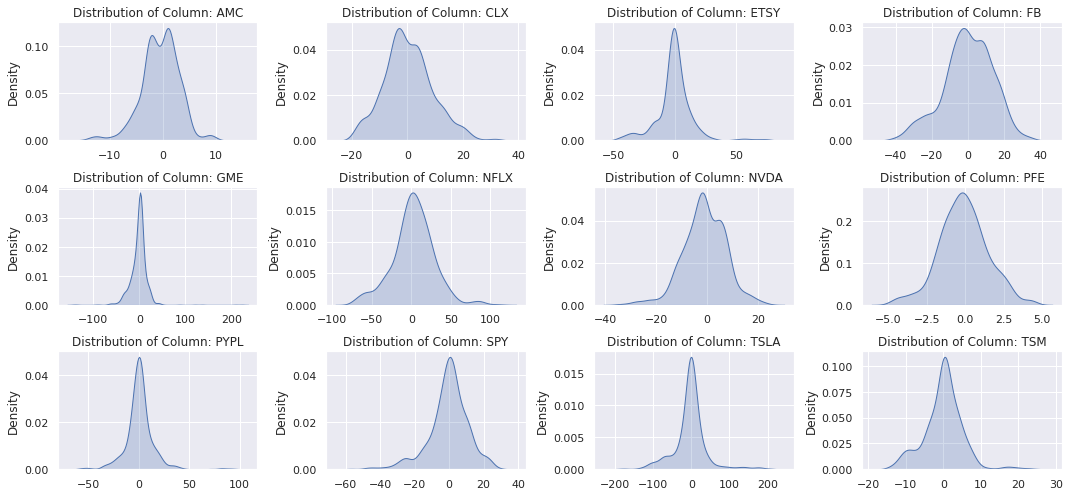

In [63]:
fig, axes = plt.subplots(nrows=3, ncols=4, figsize=(15, 7), sharex=False, sharey=False)
axes = axes.ravel()  # array to 1D
cols = resid_df.columns  # create a list of dataframe columns to use

for col, ax in zip(cols, axes):
    data = resid_df[[col]]  # select the data
    sns.kdeplot(data=data, x=col, shade=True, ax=ax)
    ax.set(title=f'Distribution of Column: {col}', xlabel=None)
    
fig.tight_layout()
plt.show()

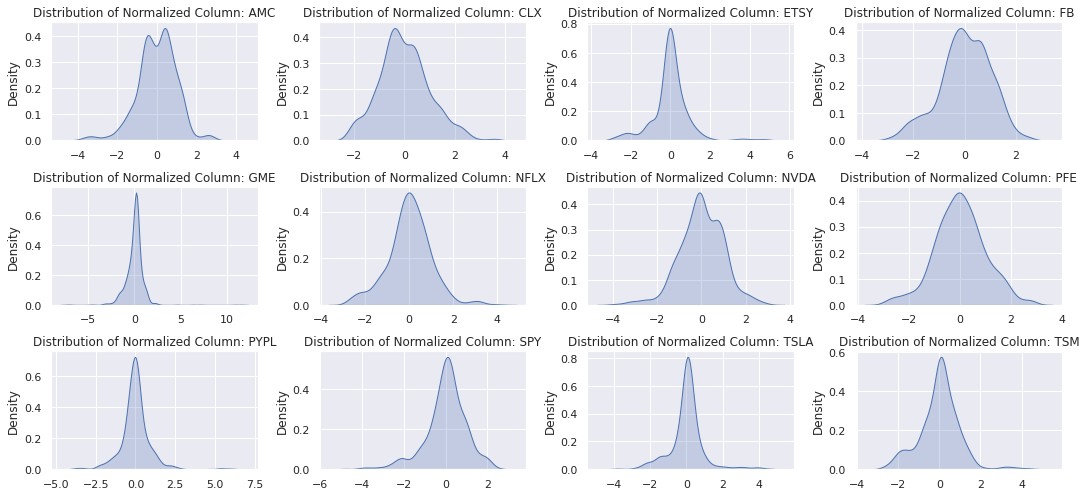

In [64]:
fig, axes = plt.subplots(nrows=3, ncols=4, figsize=(15, 7), sharex=False, sharey=False)
axes = axes.ravel()  # array to 1D
cols = resid_df.columns  # create a list of dataframe columns to use

for i, (col, ax) in enumerate(zip(cols, axes)):
    data = resid_scaled[:, i]  # select the data
    sns.kdeplot(data=data, shade=True, ax=ax)
    ax.set(title=f'Distribution of Normalized Column: {col}', xlabel=None)
    i += 1
    
fig.tight_layout()
plt.show()

In [65]:
resid_scaled.shape, resid_df.iloc[715].name

((1259, 12), '2019-12-24')

In [66]:
# fit GraphicalLasso on FIRST HALF(-ish) of data - up to XMAS 2019
ret = GraphicalLasso(max_iter=1000, alpha=0.01, tol=1e-8).fit(resid_scaled[0:715, :])

# or the whole thing? Sure...
#ret = GraphicalLasso(max_iter=1000, alpha=0.01, tol=1e-8).fit(resid_scaled)

precision = ret.precision_.copy()
clust_dist_mat = np.abs(precision)
np.fill_diagonal(clust_dist_mat, 0.0)
clust_dist_mat = clust_dist_mat.max() - clust_dist_mat
np.fill_diagonal(clust_dist_mat, 0.0)

<AxesSubplot:>

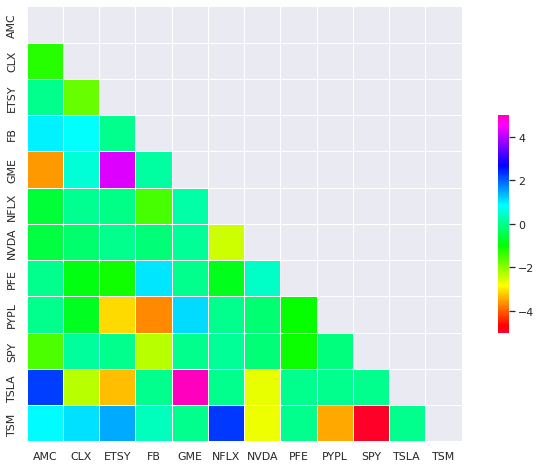

In [67]:
mask = np.triu(np.ones_like(precision, dtype=bool))
f, ax = plt.subplots(figsize=(13, 8))
cmap = sns.diverging_palette(230, 20, as_cmap=True)
sns.heatmap(precision, mask=mask, cmap='gist_rainbow', vmin=-5.0, vmax=5.0, center=0,
            square=True, linewidths=.5, cbar_kws={"shrink": .5}, xticklabels=resid_df.columns, 
            yticklabels=resid_df.columns)

<AxesSubplot:>

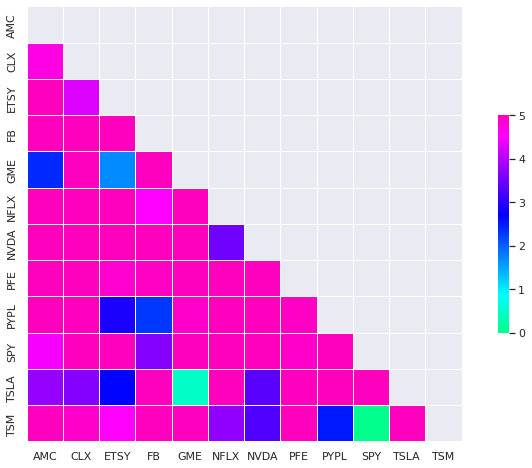

In [68]:
mask = np.triu(np.ones_like(clust_dist_mat, dtype=bool))
f, ax = plt.subplots(figsize=(13, 8))
cmap = sns.diverging_palette(230, 20, as_cmap=True)
sns.heatmap(clust_dist_mat, mask=mask, cmap='gist_rainbow', vmin=0.0, vmax=5.0, center=0.0,
            square=True, linewidths=.5, cbar_kws={"shrink": .5}, xticklabels=resid_df.columns, 
            yticklabels=resid_df.columns)

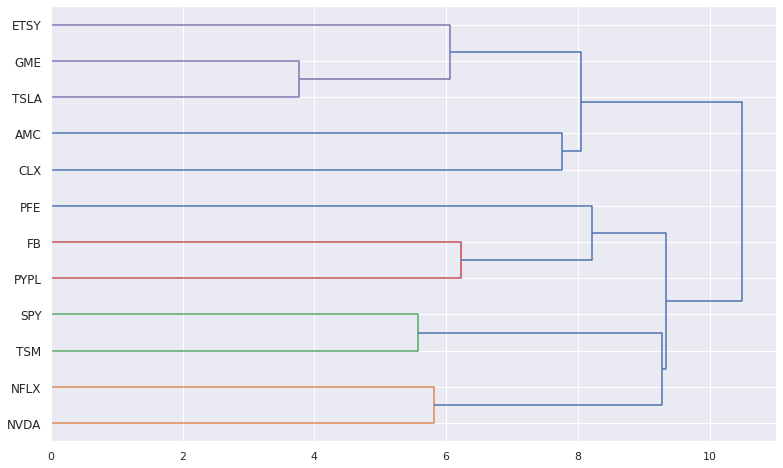

In [69]:
pairwise_distances = sch.distance.pdist(clust_dist_mat)
Z = linkage(pairwise_distances,
            method='average'  # dissimilarity metric: max distance across all pairs of 
                               # records between two clusters
    )
# calculate full dendrogram and visualize it
plt.figure(figsize=(13, 8))
dendrogram(
            Z,
            orientation='right',
            labels=resid_df.columns,
            distance_sort='descending',
            show_leaf_counts=False
          )
plt.show()

In [70]:
cutree1 = hierarchy.cut_tree(Z, n_clusters=2).squeeze()
cutree1, resid_df.columns

(array([0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1]),
 Index(['AMC', 'CLX', 'ETSY', 'FB', 'GME', 'NFLX', 'NVDA', 'PFE', 'PYPL', 'SPY',
        'TSLA', 'TSM'],
       dtype='object'))

In [71]:
prec = ret.precision_
basis_matrices = []
for i in range(max(set(cutree1))+1): # iterate over clusters
    idxs = np.where(cutree1 == i)[0] # indexes for given cluster
    A = np.zeros(prec.shape) # blank A matrix
    for idx in idxs: # loop over indexes
        for idx2 in idxs: # loop over indexes
            A[idx][idx2] = prec[idx][idx2] # set i,j entry to be the entry from precision matrix for given cluster
    basis_matrices.append(A)
basis_matrices = np.array(basis_matrices)

<AxesSubplot:>

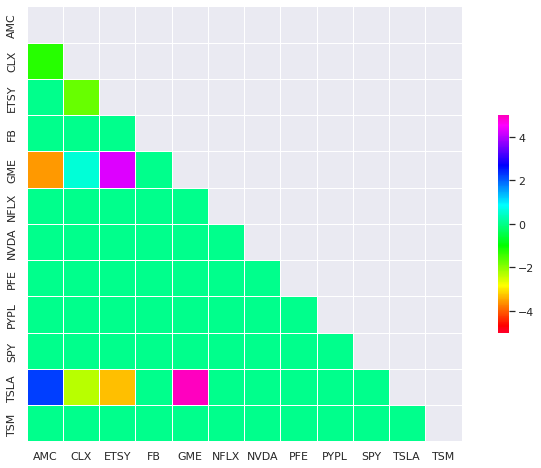

In [72]:
mask = np.triu(np.ones_like(basis_matrices[0], dtype=bool))
f, ax = plt.subplots(figsize=(13, 8))
cmap = sns.diverging_palette(230, 20, as_cmap=True)
sns.heatmap(basis_matrices[0], mask=mask, cmap='gist_rainbow', vmin=-5.0, vmax=5.0, center=0,
            square=True, linewidths=.5, cbar_kws={"shrink": .5}, xticklabels=resid_df.columns, 
            yticklabels=resid_df.columns)

<AxesSubplot:>

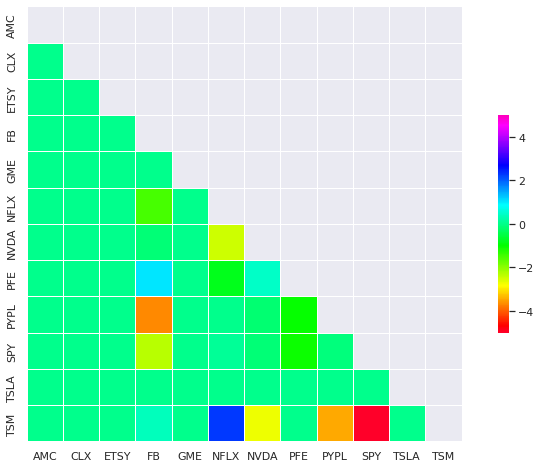

In [73]:
mask = np.triu(np.ones_like(basis_matrices[1], dtype=bool))
f, ax = plt.subplots(figsize=(13, 8))
cmap = sns.diverging_palette(230, 20, as_cmap=True)
sns.heatmap(basis_matrices[1], mask=mask, cmap='gist_rainbow', vmin=-5.0, vmax=5.0, center=0,
            square=True, linewidths=.5, cbar_kws={"shrink": .5}, xticklabels=resid_df.columns, 
            yticklabels=resid_df.columns)

In [74]:
leftover_basis_matrix = precision - basis_matrices.sum(axis=0)

<AxesSubplot:>

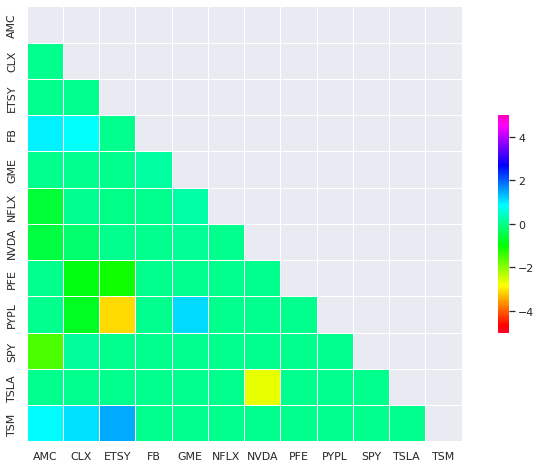

In [75]:
mask = np.triu(np.ones_like(leftover_basis_matrix, dtype=bool))
f, ax = plt.subplots(figsize=(13, 8))
cmap = sns.diverging_palette(230, 20, as_cmap=True)
sns.heatmap(leftover_basis_matrix, mask=mask, cmap='gist_rainbow', vmin=-5.0, vmax=5.0, center=0,
            square=True, linewidths=.5, cbar_kws={"shrink": .5}, xticklabels=resid_df.columns, 
            yticklabels=resid_df.columns)

In [76]:
basis_matrices_full = np.concatenate((basis_matrices, np.expand_dims(leftover_basis_matrix, 0)), 0)
basis_matrices_full.sum(axis=0) == ret.precision_

array([[ True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True],
       [ True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True],
       [ True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True],
       [ True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True],
       [ True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True],
       [ True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True],
       [ True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True],
       [ True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True],
       [ True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True],
       [ True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True

In [77]:
is_pos_def(basis_matrices_full.sum(axis=0))

True

In [78]:
for mat in basis_matrices_full:
    print(is_symmetric(mat))

True
True
True


In [79]:
"""
As it turns out, this all holds true (pos_def specifically) and is great up here

But, when performing the optimization, the precision matrix from the summation is no longer positive definite
(BIG issue)

No idea how to fix this

Also the iterative solution runs into a case where the matrix is singular (identifiability problems?)

Also no idea how to fix this
""";

In [87]:
def gradient_descent_step_single(coeffs_zero, H_s, C, M, alpha, N, to_change=None):
    coeffs_new = np.zeros(coeffs_zero.shape)
    psi_hat = (coeffs_zero.reshape(-1, 1, 1)*H_s).sum(0)
    diff = 0
    for h in range(M):
        if to_change == None or to_change == h:
            grad_log_l_h = np.trace(inv(psi_hat).dot(H_s[h])) - np.trace(H_s[h].dot(C))
            #grad_log_l_h = grad_log_l_h*(N/2)
            diff += np.abs(alpha*grad_log_l_h)
            coeffs_new[h] = coeffs_zero[h] + alpha*grad_log_l_h
        else:
            coeffs_new[h] = coeffs_zero[h]
        
    return coeffs_new, diff

def gradient_descent_single(coeffs_zero, H_s, C, M, N, dim, alpha=0.01, iters=15, to_change=None):
    coeffs_imo = coeffs_zero
    best_likelihood = calc_likelihood_precision(coeffs_imo, H_s, C, N=N, P=dim)
    best_coeffs = coeffs_imo.copy()
    for i in range(iters):
        #print(coeffs_imo)
        coeffs_imo, diff = gradient_descent_step_single(coeffs_imo, H_s, C, M, alpha=alpha, 
                                                        N=N, to_change=to_change)
        new_likelihood = calc_likelihood_precision(coeffs_imo, H_s, C, N=N, P=dim)
        better = False
        if new_likelihood > best_likelihood:
            best_likelihood = new_likelihood
            best_coeffs = coeffs_imo.copy()
            better = True
        #print(diff, better, best_coeffs, coeffs_imo)
    #print(coeffs_imo)
    
    return best_coeffs

def calc_matrices_precision(psi_hat, H_s, C, dim):
    A = np.zeros((dim, dim))
    B = np.zeros((dim,))
    inv_psi_hat = inv(psi_hat) # calculate psi_hat inverse
    for g in range(dim):
        for h in range(dim):
            mult = ((inv_psi_hat.dot(H_s[g])).dot(inv_psi_hat)).dot(H_s[h])
            lhs = np.trace(mult)
            A[g, h] = lhs
        rhs = np.trace(inv_psi_hat.dot(H_s[g])) - np.trace(C.dot(H_s[g]))
        B[g] = rhs
    
    return A, B

def iterative_soln_precision(coeffs_zero, H_s, C, dim, iters=5):
    s_imo = coeffs_zero
    for it in range(iters):
        psi_hat = (s_imo.reshape(-1, 1, 1)*H_s).sum(0) # calculate psi_hat
        A, B = calc_matrices_precision(psi_hat, H_s, C, dim)
        t_i = inv(A).dot(B)
        s_i = s_imo + t_i
        s_imo = s_i
        
    return s_imo

def iterative_soln_precision_single(coeffs_zero, H_s, C, dim, modify_index=0, iters=5):
    s_imo = coeffs_zero
    for it in range(iters):
        psi_hat = (s_imo.reshape(-1, 1, 1)*H_s).sum(0) # calculate psi_hat
        A, B = calc_matrices_precision(psi_hat, H_s, C, dim)
        t_i = inv(A).dot(B)
        s_i = s_imo.copy()
        s_i[modify_index] = s_imo[modify_index] + t_i[modify_index]
        #print(s_i)
        s_imo = s_i
        
    return s_imo

def unbiased_init_precision(C, H_s, N, dim):
    A = np.zeros((dim, dim))
    B = np.zeros((dim, ))
    for g in range(dim):
        for h in range(dim):
            A[g, h] = np.trace(H_s[g].dot(H_s[h]))
        B[g] = np.trace(inv(C).dot(H_s[g]))
    return inv(A).dot(B)

def calc_likelihood_precision(coeffs, H_s, C, N, P):
    precision_hat = (coeffs.reshape(-1, 1, 1)*H_s).sum(0)
    eig_vals, eig_vecs = np.linalg.eig(precision_hat)
    assert is_pos_def(precision_hat), "Precision Matrix is not positive definite \nEigenvalues: {}".format(eig_vals)
    
#     if not is_pos_def(precision_hat):
#         print("Precision Matrix is not positive definite \nEigenvalues: {}".format(eig_vals))
#         precision_hat += np.eye(dim)*np.abs(eig_vals.min())
    first = P*np.log(2*np.pi)
    second_det = np.linalg.det(precision_hat)
    second = np.log(second_det)
    third = np.trace(np.dot(precision_hat, C))
    #log_l = -P*np.log(2*np.pi) + np.log(np.linalg.det(precision_hat)) - np.trace(np.dot(precision_hat, C))
    log_l = -first + second - third
    
    return log_l*(N/2)

def collect_precision_matrix(H_s, prec_coeffs):
    precision = (prec_coeffs.reshape(-1, 1, 1)*H_s).sum(0)
    
    return precision

def likelihood_ratio_test(likelihood_null, likelihood_alternative, dof):
    delta_d = -2*(likelihood_null-likelihood_alternative)
    
    return delta_d, chi2.pdf(delta_d, dof)

def cluster_precision(precision):
    dist_mat = np.abs(precision).max() - np.abs(precision)
    np.fill_diagonal(dist_mat, 0)
    assert is_symmetric(dist_mat), is_pos_def(dist_mat)
    
    #pairwise_distances = sch.distance.pdist(precision_one)
    pairwise_distances = squareform(dist_mat)
    Z = linkage(pairwise_distances,
                method='average'  # dissimilarity metric: max distance across all pairs of 
                                   # records between two clusters
        )

    # calculate full dendrogram and visualize it
    plt.figure(figsize=(10, 5))
    dendrogram(
                Z,
                orientation='right',
                labels=np.arange(dim),
                distance_sort='descending',
                show_leaf_counts=False
              )
    plt.show()
    
    return Z

def LRT_all_coeffs_second_order(data_total, M, dim, H_s, window_size=500, iters=15):
    lrt_vals = []
    p_vals = []
    for i in tqdm(range(0, data_total.shape[1]-2*window_size, 1)):
        start_win_indx = i
        first_end_indx = i+window_size
        last_end_indx = i+2*window_size
        data_one = data_total[:, i:i+window_size]
        data_two = data_total[:, i+window_size:i+2*window_size]
        data_full = np.concatenate((data_one, data_two), axis=1)
        C_one = np.cov(data_one)
        C_two = np.cov(data_two)
        C_full = np.cov(data_full)

        s_zero_one = unbiased_init_precision(C_one, H_s, N=data_one.shape[1], dim=M)
        s_zero_two = unbiased_init_precision(C_two, H_s, N=data_two.shape[1], dim=M)
        s_zero_total = unbiased_init_precision(C_full, H_s, N=data_full.shape[1], dim=M)

        coeffs_hat_one = iterative_soln_precision(s_zero_one, H_s, C_one, dim=M, iters=iters)
        coeffs_hat_two = iterative_soln_precision(s_zero_two, H_s, C_two, dim=M, iters=iters)
        coeffs_hat_total = iterative_soln_precision(s_zero_total, H_s, C_full, dim=M, iters=iters)
        null_first = calc_likelihood_precision(coeffs=coeffs_hat_total, H_s=H_s, C=C_one, 
                                           N=data_one.shape[1], P=dim)
        null_second = calc_likelihood_precision(coeffs=coeffs_hat_total, H_s=H_s, C=C_two, 
                                            N=data_two.shape[1], P=dim)
        null_likelihood = null_first + null_second
        alt_likelihood_one = calc_likelihood_precision(coeffs=coeffs_hat_one, H_s=H_s, C=C_one,
                                                       N=data_one.shape[1], P=dim)
        alt_likelihood_two = calc_likelihood_precision(coeffs=coeffs_hat_two, H_s=H_s, C=C_two, 
                                                      N=data_two.shape[1], P=dim)
            
        test_stat, p_val = likelihood_ratio_test(null_likelihood, alt_likelihood_one+alt_likelihood_two, M)
        lrt_vals.append(test_stat)
        p_vals.append(p_val)
    return lrt_vals, p_vals

def LRT_all_coeffs_first_order(data_total, M, dim, H_s, window_size=500, alpha=0.01, iters=500, 
                               use_unbiased_init=False):
    lrt_vals = []
    p_vals = []
    for i in tqdm(range(0, data_total.shape[1]-2*window_size, 1)):
        start_win_indx = i
        first_end_indx = i+window_size
        last_end_indx = i+2*window_size
        data_one = data_total[:, i:i+window_size]
        data_two = data_total[:, i+window_size:i+2*window_size]
        data_full = np.concatenate((data_one, data_two), axis=1)
        C_one = np.cov(data_one)
        C_two = np.cov(data_two)
        C_full = np.cov(data_full)

        s_zero_one = unbiased_init_precision(C_one, H_s, N=data_one.shape[1], dim=M)
        s_zero_two = unbiased_init_precision(C_two, H_s, N=data_two.shape[1], dim=M)
        s_zero_total = unbiased_init_precision(C_full, H_s, N=data_full.shape[1], dim=M)
        if not use_unbiased_init:
            coeffs_hat_one = gradient_descent_single(s_zero_one, H_s, C_one, M=M, N=data_one.shape[1], 
                                                     dim=dim, alpha=alpha, 
                                                     iters=iters, to_change=None)
            coeffs_hat_two = gradient_descent_single(s_zero_two, H_s, C_two, M=M, N=data_two.shape[1], 
                                                     dim=dim, alpha=alpha, 
                                                     iters=iters, to_change=None)
            coeffs_hat_total = gradient_descent_single(s_zero_total, H_s, C_full, M=M, N=data_full.shape[1], 
                                                       dim=dim, alpha=alpha, 
                                                       iters=iters, to_change=None)
            null_first = calc_likelihood_precision(coeffs=coeffs_hat_total, H_s=H_s, C=C_one, 
                                               N=data_one.shape[1], P=dim)
            null_second = calc_likelihood_precision(coeffs=coeffs_hat_total, H_s=H_s, C=C_two, 
                                                N=data_two.shape[1], P=dim)
            null_likelihood = null_first + null_second
            alt_likelihood_one = calc_likelihood_precision(coeffs=coeffs_hat_one, H_s=H_s, C=C_one,
                                                           N=data_one.shape[1], P=dim)
            alt_likelihood_two = calc_likelihood_precision(coeffs=coeffs_hat_two, H_s=H_s, C=C_two, 
                                                          N=data_two.shape[1], P=dim)
        else:
            null_first = calc_likelihood_precision(coeffs=s_zero_total, H_s=H_s, C=C_one, 
                                               N=data_one.shape[1], P=dim)
            null_second = calc_likelihood_precision(coeffs=s_zero_total, H_s=H_s, C=C_two, 
                                                    N=data_two.shape[1], P=dim)
            null_likelihood = null_first + null_second
            alt_likelihood_one = calc_likelihood_precision(coeffs=s_zero_one, H_s=H_s, C=C_one,
                                                           N=data_one.shape[1], P=dim)
            alt_likelihood_two = calc_likelihood_precision(coeffs=s_zero_two, H_s=H_s, C=C_two, 
                                                          N=data_two.shape[1], P=dim)
        #print(coeffs_hat_one, coeffs_hat_two, coeffs_hat_total, "\n")
        test_stat, p_val = likelihood_ratio_test(null_likelihood, alt_likelihood_one+alt_likelihood_two, M)
        lrt_vals.append(test_stat)
        p_vals.append(p_val)
    return lrt_vals, p_vals  

def LRT_individual_coeffs_second_order(data_total, M, dim, H_s, window_size=500, iters=15):
    lrt_vals = []
    p_vals = []
    for i in tqdm(range(0, data_total.shape[1]-2*window_size, 1)):
        start_win_indx = i
        first_end_indx = i+window_size
        last_end_indx = i+2*window_size
        data_one = data_total[:, i:i+window_size]
        data_two = data_total[:, i+window_size:i+2*window_size]
        data_full = np.concatenate((data_one, data_two), axis=1)
        C_one = np.cov(data_one)
        C_two = np.cov(data_two)
        C_full = np.cov(data_full)

        s_zero_total = unbiased_init_precision(C_full, H_s, N=data_full.shape[1], dim=M)
        coeffs_hat_total = iterative_soln_precision(s_zero_total, H_s, C_full, dim=M, iters=iters)
        
        # null likelihood
        null_first = calc_likelihood_precision(coeffs=coeffs_hat_total, H_s=H_s, C=C_one, 
                                               N=data_one.shape[1], P=dim)
        null_second = calc_likelihood_precision(coeffs=coeffs_hat_total, H_s=H_s, C=C_two, 
                                                N=data_two.shape[1], P=dim)
        null_likelihood = null_first + null_second
        
        test_stats_m = []
        p_vals_m = []
        # iterate over each coefficient
        for i in range(M):
            alpha_i_change_pre = iterative_soln_precision_single(coeffs_hat_total, H_s, C_one, dim=M, 
                                                                   modify_index=i, iters=iters)
            alpha_i_change_post = iterative_soln_precision_single(coeffs_hat_total, H_s, C_two, dim=M, 
                                                                    modify_index=i, iters=iters)
            # likelihood on pre data, alpha_one change
            alt_likelihood_alpha_i_pre = calc_likelihood_precision(coeffs=alpha_i_change_pre, H_s=H_s, C=C_one, 
                                                                     N=data_one.shape[1], P=dim)
            # likelihood on post data, alpha_one change
            alt_likelihood_alpha_i_post = calc_likelihood_precision(coeffs=alpha_i_change_post, H_s=H_s, C=C_two, 
                                                                      N=data_two.shape[1], P=dim)
            # total likelihood alt first coeff
            alt_likelihood_alpha_i = alt_likelihood_alpha_i_pre + alt_likelihood_alpha_i_post
            
            test_stat_i, p_val_i = first_test = likelihood_ratio_test(null_likelihood, 
                                                                      alt_likelihood_alpha_i, 2)
            test_stats_m.append(test_stat_i)
            p_vals_m.append(p_val_i)
            
        lrt_vals.append(test_stats_m)
        p_vals.append(p_vals_m)
    
    # return arrays with shape (num_tests, M)
    return np.array(lrt_vals), np.array(p_vals)

def apply_fdr_correction(p_vals_all, alpha=0.05):
    corrected_p_vals_all = []
    for i in range(p_vals_all.shape[0]):
        rejected, corrected_p_vals_i = fdrcorrection(p_vals_all[i], alpha=alpha)
        corrected_p_vals_all.append(corrected_p_vals_i)
    return np.array(corrected_p_vals_all)

In [ ]:
tr(inv(psi_hat).dot(H_h)) = tr(H_h.dot(C)) # where deriv = 0
-> tr(sigma_hat.dot(H_h)) = tr(H_h.dot(C))
psi_hat = sum(alpha_i * H_i)

In [98]:
#H_s = basis_matrices_full.copy()
H_s = basis_matrices.copy()
M = H_s.shape[0]
dim = H_s.shape[-1]
window_size = 25
data_total = resid_scaled.T

In [99]:
H_s_stacked = np.zeros((dim**2, M))
for i in range(M):
    A = H_s[i]
    H_s_stacked[:, i] = A.flatten()
np.linalg.matrix_rank(H_s_stacked) == M

True

In [100]:
is_pos_def(H_s.sum(axis=0))

True

In [101]:
lrt_vals, p_vals = LRT_all_coeffs_second_order(data_total, M=M, dim=dim, H_s=H_s, 
                                              window_size=window_size)

  0%|          | 0/1209 [00:00<?, ?it/s]

LinAlgError: SVD did not converge

In [102]:
lrt_vals, p_vals = LRT_all_coeffs_first_order(data_total, M=M, dim=dim, H_s=H_s, 
                                              window_size=window_size, alpha=0.01, iters=100, 
                                              use_unbiased_init=False)

  0%|          | 0/1209 [00:00<?, ?it/s]

AssertionError: Precision Matrix is not positive definite 
Eigenvalues: [-9.13307092e-01 -7.33673422e-01 -4.23431219e-01 -9.44500217e-02
 -1.05775986e-01  1.34246261e+02  9.20098233e+01  4.79467315e+01
  2.41102939e+01  3.56330767e+00  8.89502048e+00  1.09786401e+01]

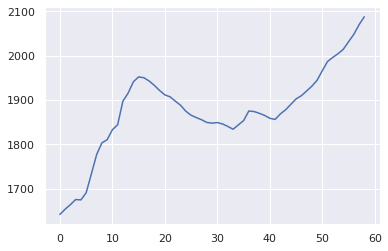

In [42]:
plt.plot(lrt_vals)

In [43]:
lrt_vals

[1641.9317988085386,
 1653.8277564812088,
 1663.9201592244572,
 1675.5104252674428,
 1674.63864967259,
 1690.7636467755874,
 1733.4637848567181,
 1776.8363692435232,
 1803.1783083718328,
 1810.3663714420181,
 1832.7941047147287,
 1844.079994348198,
 1897.1930712662506,
 1915.5066725109791,
 1940.8857415976454,
 1951.9827354738736,
 1949.9881557254776,
 1942.7350745339063,
 1932.7220972485993,
 1921.217624882287,
 1911.428457936112,
 1906.9881590566401,
 1897.1532176396213,
 1887.8976991560994,
 1874.4898159321237,
 1865.4440098568848,
 1860.2078072801814,
 1855.3120078658321,
 1849.182644402841,
 1847.714371485894,
 1848.919329589513,
 1845.8608133742418,
 1840.1909025823843,
 1833.9608096202574,
 1843.6768576553623,
 1853.307594576654,
 1875.0073099830515,
 1873.8557342282547,
 1869.8461043107345,
 1865.2257607015636,
 1858.6511132267842,
 1855.9740008887165,
 1868.3877869054595,
 1877.6642235727777,
 1890.0439918864613,
 1902.268871356413,
 1909.462828726566,
 1919.921618444554,
 193